<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 54 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Standardized Exam Scores: the Normal 🎓</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Test scores from thousands of students pile up into the famous bell curve. This is the normal distribution. We fit it, apply the empirical rule, convert scores to percentiles, and set grade boundaries.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/academic_standardized_testing.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"academic_standardized_testing.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,student_id,test_center,gender,exam_score
0,STU_70000,Center_East,F,152.00
1,STU_70001,Center_North,F,150.59
2,STU_70002,Center_North,F,151.96
3,STU_70003,Center_East,F,139.41
4,STU_70004,Center_North,F,164.99


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FIT THE BELL CURVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two parameters, mu and sigma</div>
<div style="color:#4a5578;margin-top:6px">The normal is set by its mean mu and standard deviation sigma. Estimate them from the sample, overlay the PDF, and the bell drops onto the histogram of scores.</div>
</div>

In [2]:
x = df["exam_score"]
mu, sigma = x.mean(), x.std()
print(f"students : {len(x):,}")
print(f"mean mu   : {mu:.2f}")
print(f"std sigma : {sigma:.2f}")
print(f"median    : {x.median():.2f}  (mean ~ median => symmetric)")
print(f"skewness  : {stats.skew(x):.3f}  (near 0 => not lopsided)")

students : 1,000
mean mu   : 150.20
std sigma : 8.37
median    : 150.50  (mean ~ median => symmetric)
skewness  : 0.067  (near 0 => not lopsided)


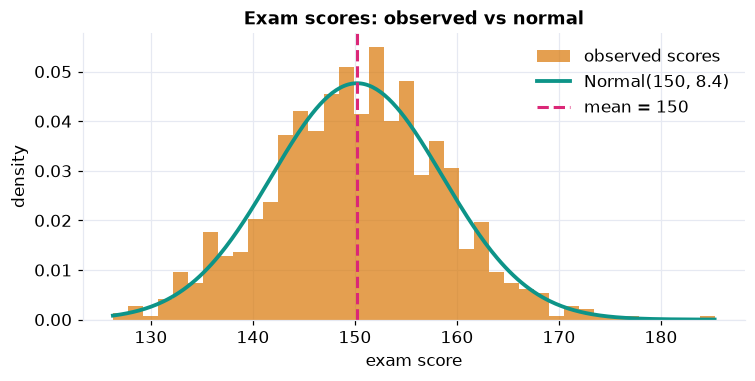

In [3]:
fig,ax=plt.subplots(figsize=(7,3.6))
ax.hist(x,bins=40,density=True,color=AMBER,alpha=0.7,label="observed scores")
xs=np.linspace(x.min(),x.max(),300); ax.plot(xs,stats.norm.pdf(xs,mu,sigma),color=TEAL,lw=2.5,label=f"Normal({mu:.0f}, {sigma:.1f})")
ax.axvline(mu,color=PINK,ls="--",lw=2,label=f"mean = {mu:.0f}")
ax.set_xlabel("exam score"); ax.set_ylabel("density"); ax.set_title("Exam scores: observed vs normal"); ax.legend()
plt.tight_layout(); plt.show()

Mean and median both sit near **150** with skewness near zero, the symmetry that signals a normal, and the fitted bell tracks the histogram. Two numbers, &#956; &#8776; 150 and &#963; &#8776; 8.4, describe every student's position.

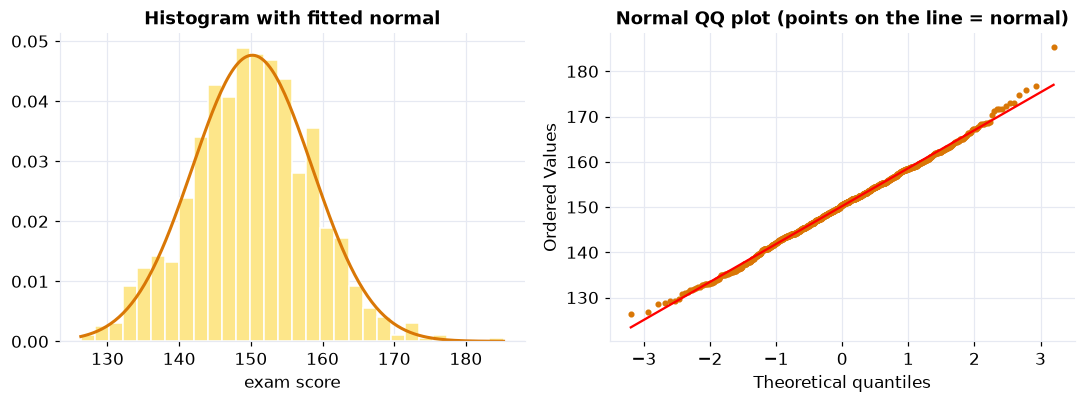

Shapiro-Wilk normality test: W = 0.998, p = 0.200  -> cannot reject normality (looks normal)
skewness = +0.067 (0 = symmetric), excess kurtosis = +0.189 (0 = normal tails)


In [4]:
# Is it REALLY normal? A QQ plot lines the data's quantiles up against a normal's,
# and a formal goodness-of-fit test puts a number on it.
fig, ax = plt.subplots(1, 2, figsize=(10,3.8))
ax[0].hist(x, bins=30, density=True, color="#fde68a", edgecolor="white")
xs = np.linspace(x.min(), x.max(), 200)
ax[0].plot(xs, stats.norm.pdf(xs, x.mean(), x.std(ddof=1)), color=AMBER, lw=2)
ax[0].set_title("Histogram with fitted normal"); ax[0].set_xlabel("exam score")
stats.probplot(x, dist="norm", plot=ax[1])
ax[1].get_lines()[0].set_color(AMBER); ax[1].get_lines()[0].set_markersize(3)
ax[1].set_title("Normal QQ plot (points on the line = normal)")
plt.tight_layout(); plt.show()
sw = stats.shapiro(x)
print(f"Shapiro-Wilk normality test: W = {sw.statistic:.3f}, p = {sw.pvalue:.3f}  -> "
      + ("cannot reject normality (looks normal)" if sw.pvalue>0.05 else "reject normality"))
print(f"skewness = {stats.skew(x):+.3f} (0 = symmetric), excess kurtosis = {stats.kurtosis(x):+.3f} (0 = normal tails)")

A symmetric histogram is suggestive, but the **QQ plot** is the real test: it plots the data's sorted values against the values a perfect normal would produce, so if the points hug the diagonal, the data is normal. Here they sit right on the line. The formal **Shapiro-Wilk** test agrees (W = 0.998, p = 0.20, so we cannot reject normality), and the shape numbers back it up: skewness 0.07 (symmetric) and small excess kurtosis 0.19 (near-normal tails). This is what "normally distributed" looks like when you actually check instead of assume. From here on, whenever a method assumes normality, the QQ plot is the ten-second diagnostic to run first.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · THE EMPIRICAL RULE &amp; z-SCORES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">68-95-99.7 and percentiles</div>
<div style="color:#4a5578;margin-top:6px">For any normal, 68% of values fall within 1 sigma, 95% within 2, 99.7% within 3. A z-score, (x-mu)/sigma, places a score on that universal scale and unlocks its percentile.</div>
</div>

In [5]:
for k in (1,2,3):
    frac = np.mean(np.abs(x-mu) < k*sigma)
    print(f"within +/- {k} sigma: observed {frac:.3f}  (normal {stats.norm.cdf(k)-stats.norm.cdf(-k):.3f})")
print()
for score in [135,150,165]:
    z=(score-mu)/sigma; print(f"score {score}: z = {z:+.2f}, percentile = {stats.norm.cdf(z)*100:.1f}%")

within +/- 1 sigma: observed 0.693  (normal 0.683)
within +/- 2 sigma: observed 0.948  (normal 0.954)
within +/- 3 sigma: observed 0.997  (normal 0.997)

score 135: z = -1.82, percentile = 3.5%
score 150: z = -0.02, percentile = 49.0%
score 165: z = +1.77, percentile = 96.1%


The 68-95-99.7 rule holds on the real data to within a fraction of a percent. A z-score then turns any raw score into a percentile: a **165** sits about 1.8&#963; above the mean, around the **96th percentile**, comparable across exams of any scale.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · SETTING GRADE BOUNDARIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Inverting the CDF</div>
<div style="color:#4a5578;margin-top:6px">Grading on a curve means inverting the normal: what score marks the top 10%? The percent-point function (inverse CDF) turns a target percentile into a cutoff.</div>
</div>

In [6]:
for pct in [0.90,0.75,0.25,0.10]:
    cut=stats.norm.ppf(pct,mu,sigma); print(f"{int(pct*100)}th percentile cutoff = {cut:.1f}")
top10 = stats.norm.ppf(0.90,mu,sigma)
print(f"\nstudents scoring above the top-10% cutoff ({top10:.0f}): {(x>=top10).mean()*100:.1f}% (target 10%)")

90th percentile cutoff = 160.9
75th percentile cutoff = 155.9
25th percentile cutoff = 144.6
10th percentile cutoff = 139.5

students scoring above the top-10% cutoff (161): 9.3% (target 10%)


The top-10% cutoff is about **161**, and indeed roughly 10% of students clear it, the model and the data agree. Inverting the CDF is how standardized tests set their grade bands, scholarship thresholds, and pass marks: pick a percentile, read off the score.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Exam scores are normal. We fit &#956; &#8776; 150 and &#963; &#8776; 8.4, confirmed the 68-95-99.7 rule on the real data, converted scores to percentiles with z-scores, and inverted the CDF to set grade boundaries. The bell curve turns a pile of scores into a fair, comparable ranking.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>